# RMSE Results Graphs
Generates graphs from `pipeline_result/summary.csv` and the VideoDepthAnything evaluation results.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [17]:

!git clone -b vda-rmse-evaluation https://github.com/dev-rathod/Eco-Cars-Depth-Estimation-2026.git

%cd Eco-Cars-Depth-Estimation-2026

Cloning into 'Eco-Cars-Depth-Estimation-2026'...
remote: Enumerating objects: 625, done.
remote: Counting objects: 100% (577/577), done.
remote: Compressing objects: 100% (328/328), done.
remote: Total 625 (delta 284), reused 525 (delta 238), pack-reused 48 (from 2)
Receiving objects: 100% (625/625), 114.77 MiB | 29.77 MiB/s, done.
Resolving deltas: 100% (286/286), done.
/content/Eco-Cars-Depth-Estimation-2026/Eco-Cars-Depth-Estimation-2026/Eco-Cars-Depth-Estimation-2026


In [18]:
# summary.csv
SUMMARY_CSV = 'pipeline_result/summary.csv'

df = pd.read_csv(SUMMARY_CSV)

# Shorten the names
df['label'] = df['segment'].str.extract(r'segment-(\d+)_')[0].str[:8]

df.head()

,segment,matched_stems,calibration_frames,evaluation_pixels,selected_model,AbsRel,RMSE,delta1,label
0,segment-10161761842905385678_760_000_780_000_w...,198,5,2967303,power,0.0,0.0,1.0,10161761
1,segment-10534368980139017457_4480_000_4500_000...,199,5,3397408,power,0.0,0.0,1.0,10534368
2,segment-10649066155322078676_1660_000_1680_000...,196,5,3023089,power,0.0,0.0,1.0,10649066
3,segment-10998289306141768318_1280_000_1300_000...,198,5,3427686,power,0.0,0.0,1.0,10998289
4,segment-12892154548237137398_2820_000_2840_000...,198,5,3408967,power,0.0,0.0,1.0,12892154


## Number of pixels for each segment

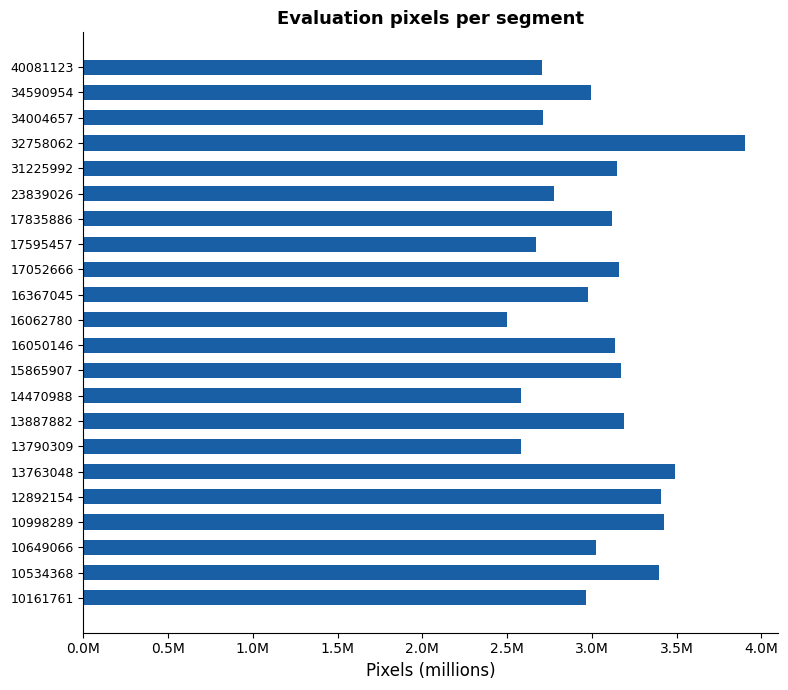

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.barh(df['label'], df['evaluation_pixels'] / 1e6, color='#185FA5', height=0.6)

ax.set_xlabel('Pixels (millions)', fontsize=12)
ax.set_title('Evaluation pixels per segment', fontsize=13, fontweight='bold')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}M'))

ax.tick_params(axis='y', labelsize=9)
ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig('evaluation_pixels.png', dpi=150, bbox_inches='tight')

plt.show()

## Matched frames per segment

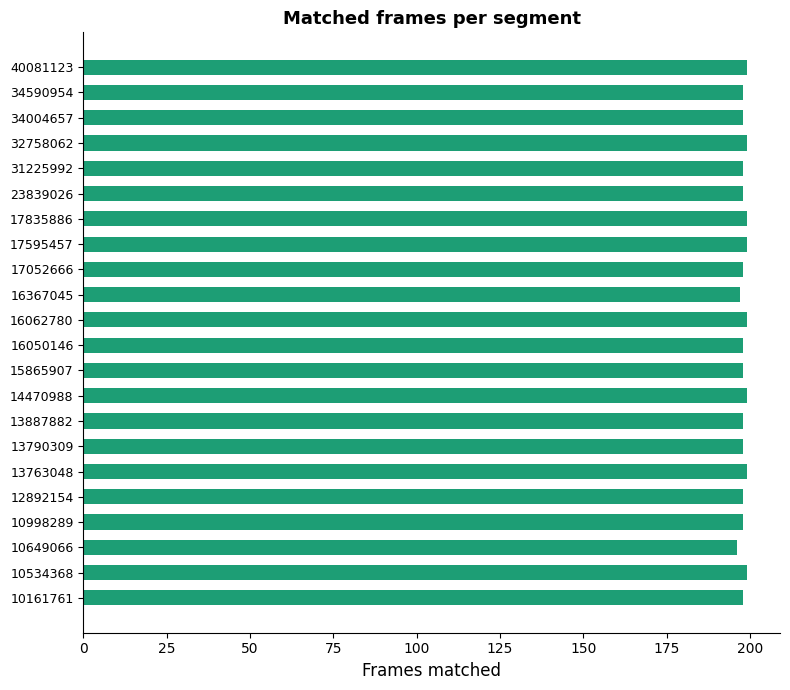

In [20]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.barh(df['label'], df['matched_stems'], color='#1D9E75', height=0.6)

ax.set_xlabel('Frames matched', fontsize=12)

ax.set_title('Matched frames per segment', fontsize=13, fontweight='bold')

ax.tick_params(axis='y', labelsize=9)

ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig('matched_frames.png', dpi=150, bbox_inches='tight')

plt.show()

## Video Depth Anything vs Batch

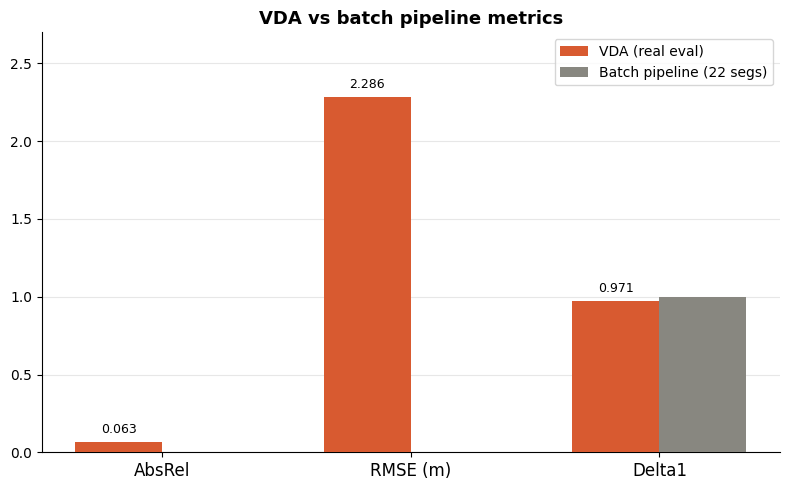

In [21]:
# Video Depth Anything results

VDA_ABSREL = 0.0630

VDA_RMSE   = 2.2860

VDA_DELTA1 = 0.9714

metrics      = ['AbsRel', 'RMSE (m)', 'Delta1']

vda_values   = [VDA_ABSREL, VDA_RMSE, VDA_DELTA1]

batch_values = [0.0, 0.0, 1.0]  # all 22 batch segments have perfect scores from the summary

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_vda   = ax.bar(x - width/2, vda_values,   width, label='VDA (real eval)',          color='#D85A30', zorder=3)
bars_batch = ax.bar(x + width/2, batch_values, width, label='Batch pipeline (22 segs)', color='#888780', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)

ax.set_title('VDA vs batch pipeline metrics', fontsize=13, fontweight='bold')

ax.set_ylim(0, 2.7)
ax.legend(fontsize=10)

ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)

ax.grid(axis='y', alpha=0.3, zorder=0)

for bar in bars_vda:

    h = bar.get_height()

    ax.text(bar.get_x() + bar.get_width()/2, h + 0.04, f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()

plt.savefig('vda_vs_batch_metrics.png', dpi=150, bbox_inches='tight')

plt.show()


## All three graphs

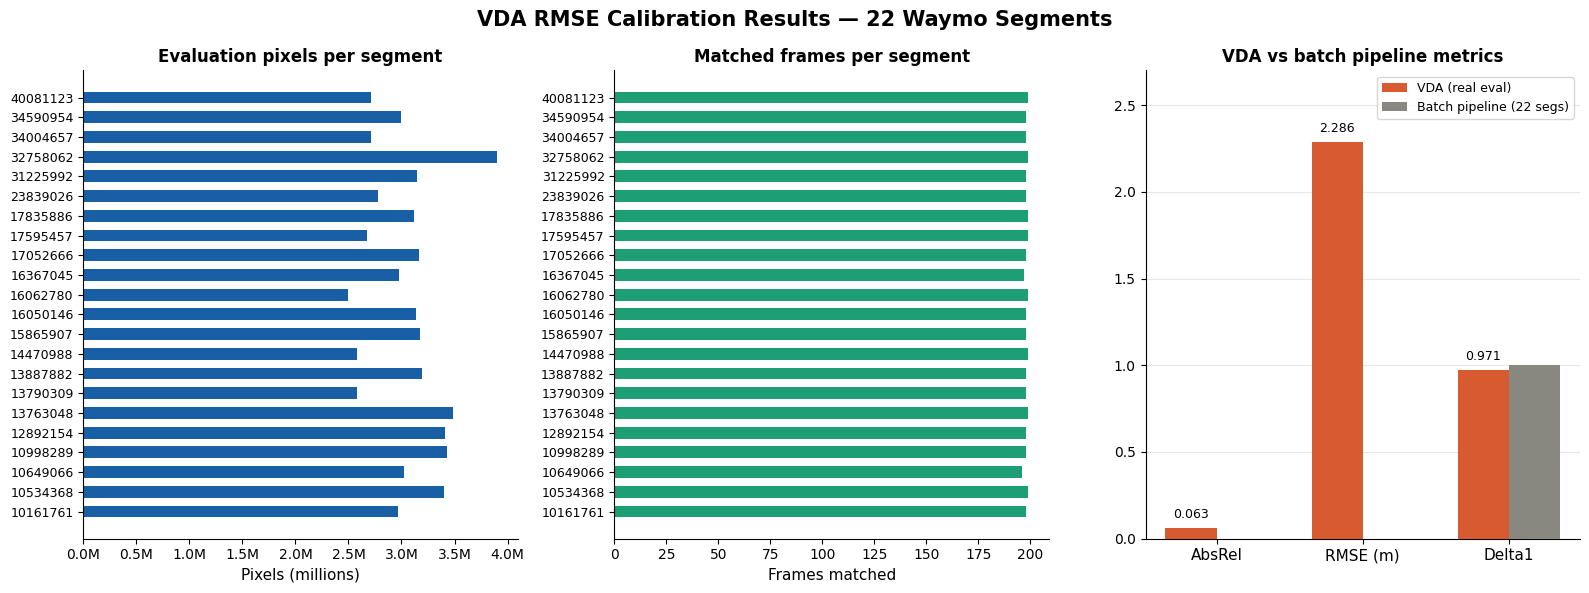

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('VDA RMSE Calibration Results — 22 Waymo Segments', fontsize=15, fontweight='bold')

# Pixels of segments
axes[0].barh(df['label'], df['evaluation_pixels'] / 1e6, color='#185FA5', height=0.6)

axes[0].set_xlabel('Pixels (millions)', fontsize=11)

axes[0].set_title('Evaluation pixels per segment', fontsize=12, fontweight='bold')

axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}M'))

axes[0].tick_params(axis='y', labelsize=9)
axes[0].spines['top'].set_visible(False)

axes[0].spines['right'].set_visible(False)

# Matched frames of the segments
axes[1].barh(df['label'], df['matched_stems'], color='#1D9E75', height=0.6)
axes[1].set_xlabel('Frames matched', fontsize=11)

axes[1].set_title('Matched frames per segment', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=9)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Video Depth Anything vs batch
x = np.arange(len(metrics))
bars_vda   = axes[2].bar(x - width/2, vda_values,   width, label='VDA (real eval)',          color='#D85A30', zorder=3)

bars_batch = axes[2].bar(x + width/2, batch_values, width, label='Batch pipeline (22 segs)', color='#888780', zorder=3)

axes[2].set_xticks(x)

axes[2].set_xticklabels(metrics, fontsize=11)
axes[2].set_title('VDA vs batch pipeline metrics', fontsize=12, fontweight='bold')

axes[2].set_ylim(0, 2.7)
axes[2].legend(fontsize=9)
axes[2].spines['top'].set_visible(False)

axes[2].spines['right'].set_visible(False)

axes[2].grid(axis='y', alpha=0.3, zorder=0)

for bar in bars_vda:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, h + 0.04, f'{h:.3f}', ha='center', va='bottom', fontsize=9)


plt.tight_layout()

plt.savefig('rmse_results_all.png', dpi=150, bbox_inches='tight')

plt.show()
